# Train a diffusion model with Dew

**This is part 2 of the series, and so I would strongly recommend going through [Notebook 01](01-diffusion-from-scratch.ipynb) first. We carry on from the ideas we built there, the forward and reverse diffusion processes, noise schedules and samplers, and I will only recap them briefly here.**

In the previous notebook, we built a diffusion model completely by hand: the noise schedule, the loss, the network and the samplers, every piece written from scratch so that we could see exactly what each one does. That is honestly the best way to understand how these models work, but you wouldn't want to write all of it again every time you train a model. And that's where Dew comes in. Each of those pieces already exists in Dew, so this time we can focus on the training run itself.

In this notebook, we shall train a small diffusion transformer on Oxford Flowers at 64x64, look at how the loss behaves, generate flowers from pure noise, and then reload the trained weights from the checkpoint.

**The notebook expects one NVIDIA GPU. On an RTX 4080 shared with other jobs the whole notebook took about twenty minutes, most of it training.**

## Install Dependencies

This installs Dew from GitHub with two of its extras: `cuda13`, which brings JAX's CUDA 13 plugin along with the CUDA libraries it needs, and `streaming`, which brings Hugging Face `datasets` to download the flower images.

In [ ]:
%pip install -q "dew-ml[cuda13,streaming] @ git+https://github.com/AshishKumar4/dew"

## Settings

I have kept every number this notebook uses in this one cell, so that you can change the whole run from one place. The images are 64x64, a batch holds 64 of them, and we train for 6,000 steps.

In [1]:
import os

IMAGE_SIZE = 64
BATCH_SIZE = 64
STEPS = 6000
LEARNING_RATE = 3e-4
SAMPLE_STEPS = 40
RUN_DIR = "runs/02-diffusion"
SEED = 0

# The tutorial test sets DEW_TUTORIAL_SMOKE=1 to run every cell in minutes on a CPU.
if os.environ.get("DEW_TUTORIAL_SMOKE") == "1":
    BATCH_SIZE, STEPS, SAMPLE_STEPS = 8, 4, 4


In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

print(jax.devices())

[CudaDevice(id=0)]


## Some Important Utils

A small helper to draw a batch of images in a grid. Dew keeps images as uint8 in `[0, 255]` when they come out of the data pipeline, but the model works in `[-1, 1]`, so the helper accepts both.

In [3]:
from dew.artifacts import uint8_pixels

def show_images(images, columns=8, title=None):
    images = np.asarray(images)
    if images.dtype != np.uint8:
        images = uint8_pixels(images)
    rows = (len(images) + columns - 1) // columns
    figure, axes = plt.subplots(rows, columns, figsize=(columns * 1.2, rows * 1.2))
    for axis in np.ravel(axes):
        axis.axis("off")
    for axis, image in zip(np.ravel(axes), images):
        axis.imshow(image)
    if title:
        figure.suptitle(title)
    plt.show()

## Data Pipeline

Just like in notebook 01, we will use the Oxford Flowers dataset, which has about 8,000 photos of 102 kinds of flowers. This time we read a copy from the Hugging Face Hub, `pranked03/flowers-blip-captions`, which also carries a caption for every photo. We don't need the captions yet, but notebook 03 uses them to ask for flowers in words.

`HFImages` describes the dataset: where it lives, the image size, and how to read it. `load(batch=...)` turns that description into a `Dataset`, and its `train(DataPartition())` gives us an endless, shuffled stream of batches. `DataPartition()` simply means that one process reads every row, which is our case with one GPU. Each record is resized to 64x64 and randomly flipped. `Loading(workers=0, threads=16)` reads the records with 16 threads inside this process, which is plenty for images this small.

**The first run downloads about 270 MB.**

In [4]:
from dew.data import DataPartition, HFImages, Loading

data = HFImages(
    name="pranked03/flowers-blip-captions",
    image_size=IMAGE_SIZE,
    val_batches=0,
    loading=Loading(workers=0, threads=16, read_buffer=64),
).load(batch=BATCH_SIZE)

print(data.records, "images,", data.steps_per_epoch, "steps per epoch")

/content/batch/job-1/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


6552 images, 102 steps per epoch


(64, 64, 64, 3) uint8


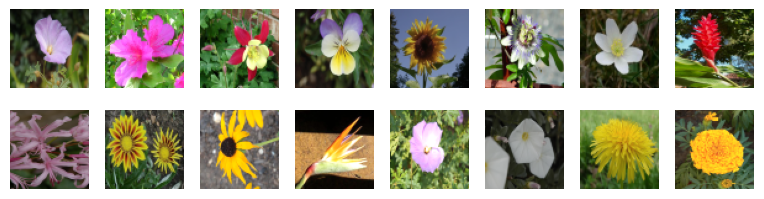

In [5]:
batch = next(iter(data.train(DataPartition())))
print(batch["image"].shape, batch["image"].dtype)
show_images(batch["image"][:16])

## The Noise Process

Let's quickly recap what we learned in notebook 01. A diffusion model learns to undo noise. During training, we take a clean image $x_0$, pick a noise level, and make a noisy image

$x_t = \alpha_t x_0 + \sigma_t \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$

where:
- $x_t$ is the noisy image at time $t$,
- $x_0$ is the clean image,
- $\alpha_t$ and $\sigma_t$ are the signal and noise rates at time $t$,
- $\epsilon$ is Gaussian noise.

The model sees $x_t$ and the noise level and has to recover the clean image. Sampling then starts from pure noise at the highest noise level and removes it a little at a time, which is the reverse diffusion process we integrated with our samplers in notebook 01.

In notebook 01, we wrote the noise schedule, the model's parameterization and the loss as separate pieces. Dew calls this pairing of a noise schedule, what the network predicts and how the loss is weighted a `Process`, and it ships a few of them as presets (`EDM`, `Karras`, `Cosine`, `Flow` and `Sqrt`). We will use the `EDM` preset, which follows the paper ["Elucidating the Design Space of Diffusion-Based Generative Models" by Karras et al. (2022)](https://arxiv.org/abs/2206.00364).

Unlike the cosine schedule of notebook 01, which was variance preserving, this one is variance exploding: $\alpha_t$ just stays at 1, and $\sigma$ goes from 0.002 up to 80. Training draws its noise levels from a log-normal distribution, and sampling walks the levels on the paper's $\rho = 7$ grid, which spends more of its steps at low noise. The network also doesn't predict the noise directly like our epsilon model did. The preset wraps it in the paper's preconditioning, which scales the network's input and mixes its output with the noisy image depending on $\sigma$.

`presets.EDM()` is the configuration, and calling it builds the `Process`.

In [6]:
from dew import presets

process = presets.EDM()()
schedule = process.sampler_schedule

times = process.times(8)
alphas, sigmas = schedule.rates(times)
print("sampling times:", np.round(np.asarray(times), 3))
print("alpha:", np.round(np.asarray(alphas), 3))
print("sigma:", np.round(np.asarray(sigmas), 3))

sampling times: [1.    0.857 0.714 0.571 0.429 0.286 0.143 0.   ]
alpha: [1. 1. 1. 1. 1. 1. 1. 1.]
sigma: [8.0000e+01 3.4992e+01 1.3699e+01 4.6370e+00 1.2870e+00 2.6700e-01
 3.5000e-02 2.0000e-03]


Here is one flower at each of those eight noise levels, from the most noise on the left to the least on the right. The images are clipped to `[-1, 1]` for display, so the leftmost ones look like plain static. And they really are: at $\sigma = 80$ the noise has a standard deviation of 80 while the pixels lie in `[-1, 1]`, so there is basically nothing of the flower left to see.

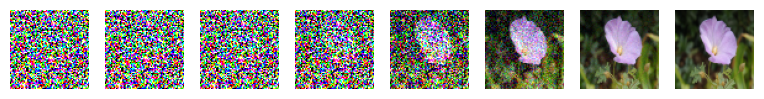

In [7]:
image = batch["image"][0].astype(np.float32) / 127.5 - 1
noise = jax.random.normal(jax.random.key(SEED), image.shape)
noisy = [alpha * image + sigma * noise for alpha, sigma in zip(alphas, sigmas)]
show_images(np.clip(np.stack(noisy), -1, 1), columns=8)

## Modeling

In notebook 01, we built a UNet for our denoising model. This time we use a small diffusion transformer (DiT), the architecture from the paper ["Scalable Diffusion Models with Transformers" by Peebles and Xie](https://arxiv.org/abs/2212.09748): a plain stack of transformer blocks conditioned on the noise level with adaLN-Zero. It cuts the 64x64 image into 4x4 patches, which gives us 256 tokens, runs them through six transformer layers, and returns one prediction per pixel. `models.build("simple_dit", ...)` looks the model up in Dew's registry by name. We compute in bfloat16, and `attention_impl="auto"` lets Dew pick the fastest attention kernel for your GPU.

`InputSpec(Field("image", (64, 64, 3)))` tells the objective which batch field to generate and what shape it has. Note that this model has no conditions: it learns what flowers look like in general, but we can't ask it for a particular one. We will get to that in notebook 03.

In [8]:
from dew import Field, InputSpec, models

model = models.build(
    "simple_dit",
    patch_size=4,
    emb_features=256,
    num_layers=6,
    num_heads=4,
    output_channels=3,
    dtype="bfloat16",
    attention_impl="auto",
)
inputs = InputSpec(Field("image", (IMAGE_SIZE, IMAGE_SIZE, 3)))

## The Objective and the Trainer

`DiffusionObjective` holds the diffusion loss, the one we wrote by hand in notebook 01: it draws a noise level for each image, makes the noisy image, runs the model and weights the error. It also asks the trainer to keep an exponential moving average (EMA) of the weights. The EMA copy changes slowly and usually gives cleaner samples than the live weights, which is why we sample with it later. `sampler`, `guidance` and `steps` only say how the objective samples when it previews images; they don't change training at all.

`Trainer` does the rest: it computes the gradients, applies the AdamW optimizer, updates the EMA, and writes checkpoints to `RUN_DIR`. `LocalTracker` records every logged number in a JSON file, which we will plot after training.

In [9]:
import optax
from dew import Checkpoints, LocalTracker, Trainer
from dew.objectives.diffusion import DiffusionObjective
from dew.sampling import EulerAncestral

objective = DiffusionObjective(
    model, process, inputs,
    ema_decay=0.999,
    sampler=EulerAncestral(), guidance=None, steps=SAMPLE_STEPS,
)
tracker = LocalTracker(f"{RUN_DIR}/tracking")
trainer = Trainer(
    objective, optax.adamw(LEARNING_RATE),
    key=jax.random.key(SEED),
    checkpoints=Checkpoints(RUN_DIR),
    tracker=tracker,
)

variables = jax.eval_shape(objective.init, jax.random.key(0))
n_params = sum(x.size for x in jax.tree_util.tree_leaves(variables["params"]))
print(f"{n_params / 1e6:.1f}M parameters")

8.7M parameters


## Training

`fit` trains until the step counter reaches `STEPS`, prints the loss every `log_every` steps, and writes a checkpoint at the end.

**If `RUN_DIR` already holds a checkpoint, `fit` resumes from it, so running this cell twice does not train twice.**

In [10]:
state = trainer.fit(data, steps=STEPS, log_every=500, checkpoint_every=STEPS)

Training from step 0 to 6000 on {'data': 1, 'expert': 1, 'fsdp': 1, 'tensor': 1, 'sequence': 1, 'stage': 1} (1 process(es))


step 500: loss 0.1288


step 1000: loss 0.1125


step 1500: loss 0.1207


step 2000: loss 0.1059


...

step 4500: loss 0.0956


step 5000: loss 0.1122


step 5500: loss 0.1096


step 6000: loss 0.0915


Goodput: first step after 40.80 s, 94.5% of the wall time in steps


The tracker wrote one line per log step to `scalars.jsonl`, here every 500 steps. The loss falls from about 0.13 to about 0.09, but it jumps around quite a bit on the way. Don't worry, that is expected: every batch draws new noise levels, and some noise levels are much harder to denoise than others.

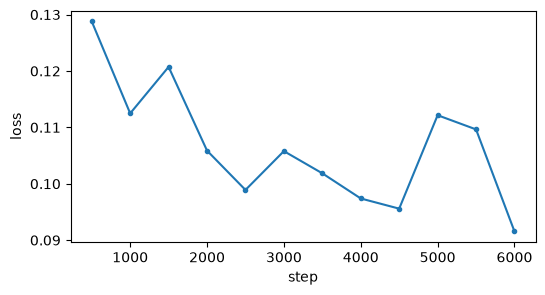

In [11]:
import json

rows = [json.loads(line) for line in open(f"{RUN_DIR}/tracking/scalars.jsonl")]
rows = [row for row in rows if "train/loss" in row["scalars"]]
plt.figure(figsize=(6, 3))
plt.plot([row["step"] for row in rows], [row["scalars"]["train/loss"] for row in rows], marker=".")
plt.xlabel("step")
plt.ylabel("loss")
plt.show()

## Generate Samples

To generate an image, we run the noise process backwards, just like we did with our samplers in notebook 01. `process.noise` draws the starting point, pure noise with the spread of the highest noise level. `process.denoiser` wraps the model and its weights into the function a sampler calls: given a noisy image and its time, it returns the model's guess of the clean image and of the noise. `sample` then runs the solver over `SAMPLE_STEPS` noise levels in one compiled loop.

The solver is `EulerAncestral`, the Euler-A sampler we talked about in notebook 01: Euler's method on the reverse diffusion SDE, so a bit of fresh noise goes back in at every step.

`state.averaged` is the weights tree with the EMA weights in place of the live ones, and `objective.trainable` keeps only the model's own weights.

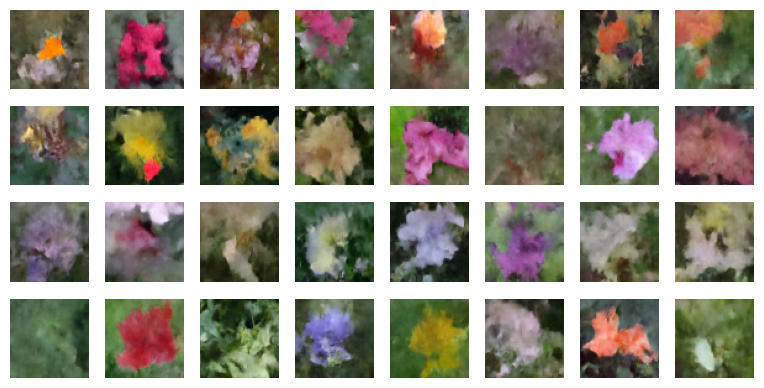

In [12]:
from dew.sampling import sample

def generate(params, count, key):
    denoise = process.denoiser(model, objective.trainable(params), {})
    x_T = process.noise(key, (count, IMAGE_SIZE, IMAGE_SIZE, 3))
    return sample(denoise, x_T, SAMPLE_STEPS, solver=EulerAncestral(), key=key)

images = generate(state.averaged, 32, jax.random.key(1))
show_images(images)

The flowers are soft and painterly, and a few are only blobs of colour. That is honestly what 6,000 steps of an 8.7M-parameter model give you; longer training and a bigger model would sharpen them.

## Reloading the checkpoint

The checkpoint in `RUN_DIR` holds the arrays: the weights, the EMA, the optimizer state and the step counters. It does not hold the code. So to reload, we build a new `Trainer` over the same objective and call `place()`, which restores the latest checkpoint onto the GPU. Sampling with the same key gives the same images, which shows that the weights came back unchanged.

In [13]:
restored, _, _ = Trainer(
    objective, optax.adamw(LEARNING_RATE),
    key=jax.random.key(SEED),
    checkpoints=Checkpoints(RUN_DIR),
).place()
print("restored step:", int(restored.step))

again = generate(restored.averaged, 32, jax.random.key(1))
print("largest difference from the samples above:", float(jnp.max(jnp.abs(again - images))))

Resumed from step 6000 in /content/site-tutorials-work/runs/02-diffusion
restored step: 6000


largest difference from the samples above: 0.0


## Where to go next

[Notebook 03](03-text-to-image-with-guidance.ipynb) trains on the captions as well, so that you can ask for a flower in words. [Notebook 04](04-samplers-and-schedules.ipynb) loads this notebook's checkpoint and compares Dew's samplers on it. And if you would rather train from the command line, `recipes/diffusion/train.py` runs the same kind of training.